# Concept Drift Detection on Synthetic Artifacts (Discriminator)

This notebook runs adjacent-year discrimination on synthetic artifacts generated in
`data drift testing on syntetic data.ipynb`.

Workflow summary:
- Load synthetic artifact manifest from `synthetic_drift_data/`
- Reuse train/val/test pixel splits from `data_split.npz`
- Run the same SGD discriminator pipeline for each artifact
- Organize execution by synthetic method type:
  - Mean/variance shift
  - Covariance shift
  - Noise injection

Each method section runs both modes when available:
- `baseline_replication`
- `per_year_original`

A high ROC-AUC indicates stronger separability between adjacent years (drift signal).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# Paths
split_path = "data_split.npz"
manifest_json_path = Path("synthetic_drift_data") / "synthetic_generation_manifest.json"
manifest_csv_path = Path("synthetic_drift_data") / "synthetic_generation_manifest.csv"

# Runtime config
SAMPLE_FRACTION = 1.0  # Use 1.0 for full split, 0.1 for quick checks

# Load manifest (consume-only workflow)
if manifest_json_path.exists():
    with open(manifest_json_path, "r", encoding="utf-8") as handle:
        manifest_obj = json.load(handle)
    manifest_df = pd.DataFrame(manifest_obj.get("rows", []))
elif manifest_csv_path.exists():
    manifest_df = pd.read_csv(manifest_csv_path)
else:
    raise FileNotFoundError(
        "Synthetic manifest not found. Expected one of:\n"
        f"  - {manifest_json_path}\n"
        f"  - {manifest_csv_path}\n"
        "Generate artifacts first in 'data drift testing on syntetic data.ipynb'."
    )

required_cols = {"mode", "method", "zarr_path", "metadata_path"}
missing_cols = sorted(required_cols - set(manifest_df.columns))
if missing_cols:
    raise ValueError(f"Manifest is missing required columns: {missing_cols}")

if manifest_df.empty:
    raise ValueError("Manifest contains no artifact rows.")

manifest_df = manifest_df.copy()
manifest_df["artifact_label"] = manifest_df["method"] + " | " + manifest_df["mode"]
manifest_df = manifest_df.sort_values(["method", "mode"]).reset_index(drop=True)

# Load data splits
splits = np.load(split_path)
train_pixel_indices = splits["train_pixel_indices"]
val_pixel_indices = splits["val_pixel_indices"]
test_pixel_indices = splits["test_pixel_indices"]

print(f"Loaded manifest rows: {len(manifest_df)}")
print(f"Split sizes: train={len(train_pixel_indices):,}, val={len(val_pixel_indices):,}, test={len(test_pixel_indices):,}")
display(manifest_df[["method", "mode", "zarr_path", "metadata_path"]])

Dataset loaded. Year range: 2016 - 2022 (7 years)
Pixels: train=5,597,776, val=1,273,437, test=1,283,992


In [ ]:
# Manifest diagnostics
method_order = ["mean_variance_shift", "covariance_shift", "noise_injection"]
mode_order = ["baseline_replication", "per_year_original"]

summary_df = (
    manifest_df.groupby(["method", "mode"], dropna=False)
    .size()
    .rename("n_artifacts")
    .reset_index()
    .sort_values(["method", "mode"])
    .reset_index(drop=True)
)

display(summary_df)

missing_files = []
for _, row in manifest_df.iterrows():
    zarr_ok = Path(row["zarr_path"]).exists()
    meta_ok = Path(row["metadata_path"]).exists()
    if not (zarr_ok and meta_ok):
        missing_files.append({
            "method": row["method"],
            "mode": row["mode"],
            "zarr_exists": zarr_ok,
            "metadata_exists": meta_ok,
        })

if missing_files:
    missing_df = pd.DataFrame(missing_files)
    display(missing_df)
    raise FileNotFoundError("Some artifact files from manifest are missing.")

print("All manifest-referenced artifact files are present.")

Test subset s2_bands shape: (100, 7, 7)
Test subset s2_bands dims: ('pixel', 'year', 's2_band')
All dims: FrozenMappingWarningOnValuesAccess({'pixel': 100, 'year': 7, 's2_band': 7})


In [ ]:
def prepare_features_for_year(ds_subset, year_idx):
    """Prepare per-pixel features for a given year index using S2 bands only."""
    if year_idx == 0:
        return None, None

    valid_mask = ds_subset.disturbances[:, year_idx].values != 255

    s2_data = ds_subset.s2_bands.values  # shape (n_pixels, n_years, n_bands)
    s2_t = s2_data[:, year_idx, :].copy()  # shape (n_pixels, n_bands)

    # Vectorized NaN imputation: per-pixel, per-band mean across years
    nan_mask = np.isnan(s2_t)
    if np.any(nan_mask):
        band_means = np.nanmean(s2_data, axis=1)  # shape (n_pixels, n_bands)
        s2_t[nan_mask] = band_means[nan_mask]

    X = s2_t
    y = ds_subset.disturbances[:, year_idx].values

    # Combined mask: valid disturbance + binary label + finite features
    keep_mask = valid_mask & np.isin(y, [0, 1]) & np.all(np.isfinite(X), axis=1)
    X = X[keep_mask]
    y = y[keep_mask]

    if len(X) == 0:
        return None, None

    return X, y


def build_pair_dataset_cached(X_prev, y_prev, X_curr, y_curr):
    """Build binary year-pair dataset from pre-computed features."""
    if X_prev is None or X_curr is None:
        return None, None

    if X_prev.shape[1] != X_curr.shape[1]:
        return None, None

    X_pair = np.vstack([X_prev, X_curr])
    y_pair = np.concatenate([
        np.zeros(len(y_prev), dtype=np.uint8),
        np.ones(len(y_curr), dtype=np.uint8),
    ])

    return X_pair, y_pair


def _sample_indices(indices, sample_fraction, rng_seed=RANDOM_STATE):
    if sample_fraction >= 1.0:
        return indices
    rng_local = np.random.default_rng(rng_seed)
    sample_size = max(1, int(len(indices) * sample_fraction))
    return rng_local.choice(indices, size=sample_size, replace=False)


def plot_artifact_auc(results_df, title_suffix=""):
    if len(results_df) == 0:
        print("No rows to plot for this artifact.")
        return

    x = np.arange(len(results_df))
    plt.figure(figsize=(10, 4.5))
    plt.plot(x, results_df["val_auc"], marker="o", label="Val AUC")
    plt.plot(x, results_df["test_auc"], marker="o", label="Test AUC")
    plt.xticks(x, results_df["pair"], rotation=45, ha="right")
    plt.ylim(0.45, 1.0)
    plt.ylabel("ROC-AUC")
    plt.title(f"Adjacent-Year Drift Discriminator AUC{title_suffix}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_discriminator_for_artifact(artifact_row, sample_fraction=SAMPLE_FRACTION):
    """Run the adjacent-year discriminator pipeline for a single synthetic artifact row."""
    artifact_row = artifact_row.copy()

    zarr_path = Path(artifact_row["zarr_path"])
    metadata_path = Path(artifact_row["metadata_path"])
    method = str(artifact_row["method"])
    mode = str(artifact_row["mode"])
    artifact_label = f"{method} | {mode}"

    with open(metadata_path, "r", encoding="utf-8") as handle:
        metadata = json.load(handle)

    ds_artifact = xr.open_zarr(zarr_path)
    year_values = ds_artifact.year.values
    n_years = len(year_values)
    n_pairs = n_years - 2

    train_sample = _sample_indices(train_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE)
    val_sample = _sample_indices(val_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE + 1)
    test_sample = _sample_indices(test_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE + 2)

    ds_train = ds_artifact.isel(pixel=train_sample)
    ds_val = ds_artifact.isel(pixel=val_sample)
    ds_test = ds_artifact.isel(pixel=test_sample)

    print(f"Artifact: {artifact_label}")
    print(f"Dataset: {zarr_path}")
    print(f"Pairs to evaluate: {n_pairs}")

    results = []
    skipped_pairs = []
    start_time = time.time()

    for pair_idx, idx_curr in enumerate(range(2, n_years), start=1):
        idx_prev = idx_curr - 1
        year_prev = int(year_values[idx_prev])
        year_curr = int(year_values[idx_curr])
        pair_name = f"{year_prev} vs {year_curr}"

        pair_start = time.time()
        print(f"\n[{pair_idx}/{n_pairs}] {pair_name}")

        X_train_prev, y_train_prev = prepare_features_for_year(ds_train, idx_prev)
        X_train_curr, y_train_curr = prepare_features_for_year(ds_train, idx_curr)
        X_train, y_train = build_pair_dataset_cached(X_train_prev, y_train_prev, X_train_curr, y_train_curr)

        X_val_prev, y_val_prev = prepare_features_for_year(ds_val, idx_prev)
        X_val_curr, y_val_curr = prepare_features_for_year(ds_val, idx_curr)
        X_val, y_val = build_pair_dataset_cached(X_val_prev, y_val_prev, X_val_curr, y_val_curr)

        X_test_prev, y_test_prev = prepare_features_for_year(ds_test, idx_prev)
        X_test_curr, y_test_curr = prepare_features_for_year(ds_test, idx_curr)
        X_test, y_test = build_pair_dataset_cached(X_test_prev, y_test_prev, X_test_curr, y_test_curr)

        if any(v is None for v in [X_train, y_train, X_val, y_val, X_test, y_test]):
            skipped_pairs.append((pair_name, "missing or invalid data after filtering"))
            print("  SKIP: missing data")
            continue

        if len(np.unique(y_train)) < 2 or len(np.unique(y_val)) < 2 or len(np.unique(y_test)) < 2:
            skipped_pairs.append((pair_name, "single class present in splits"))
            print("  SKIP: single class in one split")
            continue

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)

        model = SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=0.0001,
            max_iter=1000,
            tol=1e-3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train_scaled, y_train)

        val_proba = model.predict_proba(X_val_scaled)[:, 1]
        test_proba = model.predict_proba(X_test_scaled)[:, 1]

        val_auc = roc_auc_score(y_val, val_proba)
        test_auc = roc_auc_score(y_test, test_proba)
        val_pred = (val_proba >= 0.5).astype(int)
        test_pred = (test_proba >= 0.5).astype(int)
        val_f1 = f1_score(y_val, val_pred)
        test_f1 = f1_score(y_test, test_pred)

        pair_time = time.time() - pair_start

        results.append({
            "method": method,
            "mode": mode,
            "artifact_label": artifact_label,
            "zarr_path": str(zarr_path),
            "metadata_path": str(metadata_path),
            "pair": pair_name,
            "year_t_minus_1": year_prev,
            "year_t": year_curr,
            "n_train": int(len(y_train)),
            "n_val": int(len(y_val)),
            "n_test": int(len(y_test)),
            "val_auc": float(val_auc),
            "test_auc": float(test_auc),
            "val_f1": float(val_f1),
            "test_f1": float(test_f1),
            "time_sec": float(pair_time),
            "changed_years": metadata.get("changed_years"),
            "perturb_year_values": metadata.get("perturb_year_values"),
        })

        print(
            f"  RESULTS: Val AUC = {val_auc:.4f} | Test AUC = {test_auc:.4f} "
            f"| Val F1 = {val_f1:.4f} | Test F1 = {test_f1:.4f}"
        )

    total_time = time.time() - start_time
    results_df = pd.DataFrame(results).sort_values("year_t").reset_index(drop=True)

    print("\n" + "=" * 70)
    print(f"COMPLETE: {artifact_label}")
    print(f"Elapsed: {total_time:.1f}s ({total_time/60:.1f}m)")
    if len(results_df) > 0:
        print(f"Pairs trained: {len(results_df)}")
        print(f"Average time per pair: {results_df['time_sec'].mean():.1f}s")
        print(f"Min/Max AUC (test): {results_df['test_auc'].min():.3f} / {results_df['test_auc'].max():.3f}")
    else:
        print("No valid year pairs were found.")
    print("=" * 70 + "\n")

    return results_df, skipped_pairs


def run_method_section(method_name, sample_fraction=SAMPLE_FRACTION):
    """Run both modes for one synthetic method and return section outputs."""
    section_rows = manifest_df[manifest_df["method"] == method_name].copy()
    if section_rows.empty:
        print(f"No artifacts found for method: {method_name}")
        return {"method": method_name, "artifacts": {}, "combined": pd.DataFrame()}

    mode_rank = {"baseline_replication": 0, "per_year_original": 1}
    section_rows["_mode_rank"] = section_rows["mode"].map(mode_rank).fillna(99)
    section_rows = section_rows.sort_values(["_mode_rank", "mode"]).reset_index(drop=True)

    artifact_outputs = {}
    combined_frames = []

    for _, row in section_rows.iterrows():
        mode = row["mode"]
        print(f"\n### Running mode: {mode}")
        results_df, skipped_pairs = run_discriminator_for_artifact(row, sample_fraction=sample_fraction)

        artifact_outputs[mode] = {
            "results_df": results_df,
            "skipped_pairs": skipped_pairs,
            "row": row.to_dict(),
        }

        if len(results_df) > 0:
            display(results_df)
            plot_artifact_auc(results_df, title_suffix=f" | {method_name} | {mode}")
            combined_frames.append(results_df)

        if skipped_pairs:
            print("Skipped pairs:")
            for pair_name, reason in skipped_pairs:
                print(f"  - {pair_name}: {reason}")

    if combined_frames:
        combined = pd.concat(combined_frames, ignore_index=True)
    else:
        combined = pd.DataFrame()

    return {
        "method": method_name,
        "artifacts": artifact_outputs,
        "combined": combined,
    }

In [ ]:
# Global container for section outputs
section_results = {}

print("Ready. Run the method sections below to execute discriminator experiments.")

Starting training on 5 adjacent year pairs...


[1/5] 2017 vs 2018
----------------------------------------------------------------------
  → Preparing train features (2017 + 2018)... 11,192,640 samples in 28.0s
  → Preparing val features (2017 + 2018)... 2,546,360 samples in 10.1s
  → Preparing test features (2017 + 2018)... 2,566,882 samples in 8.0s
  → Scaling features... 1.7s
  → Training SGD logistic regression... 21.6s
  → Evaluating on val and test sets... 2.6s

  ✓ RESULTS: Val AUC = 0.6821 | Test AUC = 0.6785 | Val F1 = 0.6491 | Test F1 = 0.6545
  ✓ Pair completed in 72.5s

[2/5] 2018 vs 2019
----------------------------------------------------------------------
  → Preparing train features (2018 + 2019)... 11,192,640 samples in 19.5s
  → Preparing val features (2018 + 2019)... 2,546,360 samples in 9.2s
  → Preparing test features (2018 + 2019)... 2,566,882 samples in 8.2s
  → Scaling features... 1.8s
  → Training SGD logistic regression... 22.0s
  → Evaluating on val and test

,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec
0,2017 vs 2018,2017,2018,11192640,2546360,2566882,0.682097,0.678537,0.649091,0.654472,72.482330
1,2018 vs 2019,2018,2019,11192640,2546360,2566882,0.735258,0.722240,0.665393,0.659008,63.622833
2,2019 vs 2020,2019,2020,11192640,2546360,2566882,0.562066,0.540399,0.559659,0.537191,60.186163
3,2020 vs 2021,2020,2021,11192640,2546360,2566882,0.581209,0.571939,0.543103,0.546000,48.879776
4,2021 vs 2022,2021,2022,11192640,2546360,2566882,0.666745,0.675960,0.632131,0.640139,49.365814


## Mean/Variance Shift

Run discriminator on synthetic artifacts generated with `mean_variance_shift` for both modes.

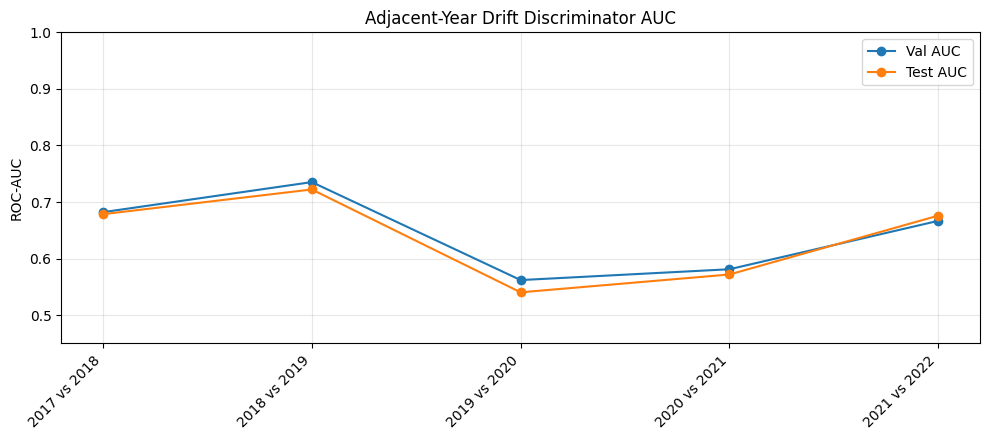

In [ ]:
print("=== Mean/Variance Shift ===")
print("Running discriminator for mean_variance_shift artifacts...")

Artifact: mean_variance_shift | per_year_original
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9071 | Test AUC = 0.9065 | Val F1 = 0.8301 | Test F1 = 0.8341

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9260 | Test AUC = 0.9322 | Val F1 = 0.8609 | Test F1 = 0.8660

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5621 | Test AUC = 0.5404 | Val F1 = 0.5596 | Test F1 = 0.5372

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9409 | Test AUC = 0.9475 | Val F1 = 0.8744 | Test F1 = 0.8843

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9314 | Test AUC = 0.9419 | Val F1 = 0.8666 | Test F1 = 0.8764

COMPLETE: mean_variance_shift | per_year_original
Elapsed: 433.7s (7.2m)
Pairs trained: 5
Average time per pair: 86.7s
Min/Max AUC (test): 0.540 / 0.948



,method,mode,artifact_label,zarr_path,metadata_path,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec,changed_years,perturb_year_values
0,mean_variance_shift,per_year_original,mean_variance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2017 vs 2018,2017,2018,11192640,2546360,2566882,0.907112,0.906465,0.830071,0.834105,82.986851,None,"[2018, 2021]"
1,mean_variance_shift,per_year_original,mean_variance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2018 vs 2019,2018,2019,11192640,2546360,2566882,0.926019,0.932237,0.860923,0.866029,90.764479,None,"[2018, 2021]"
2,mean_variance_shift,per_year_original,mean_variance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2019 vs 2020,2019,2020,11192640,2546360,2566882,0.562052,0.540432,0.559623,0.537234,88.607752,None,"[2018, 2021]"
3,mean_variance_shift,per_year_original,mean_variance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2020 vs 2021,2020,2021,11192640,2546360,2566882,0.940872,0.947508,0.874423,0.884296,79.729204,None,"[2018, 2021]"
4,mean_variance_shift,per_year_original,mean_variance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2021 vs 2022,2021,2022,11192640,2546360,2566882,0.931381,0.941915,0.866647,0.876422,91.596954,None,"[2018, 2021]"


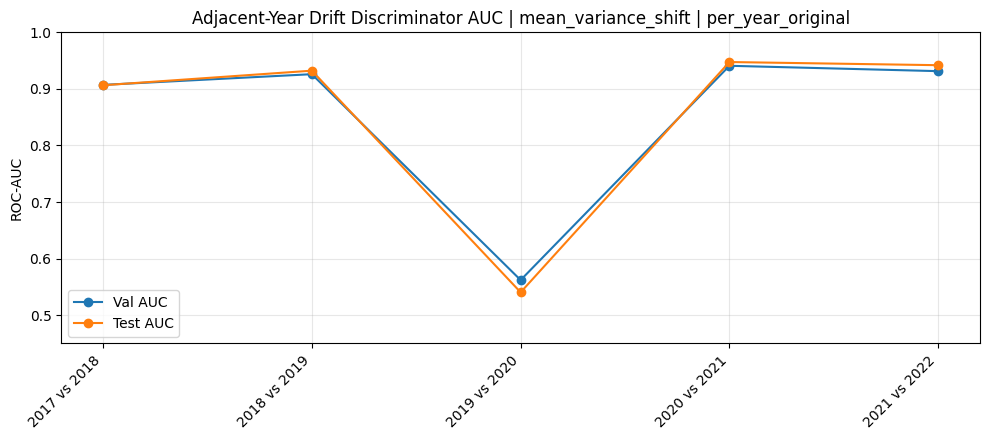

Mean/variance shift combined view:


,mode,mean_val_auc,mean_test_auc,mean_test_f1,n_pairs
0,baseline_replication,0.857040,0.859214,0.832963,5
1,per_year_original,0.853487,0.853711,0.799617,5


In [7]:
section_results["mean_variance_shift"] = run_method_section(
    method_name="mean_variance_shift",
    sample_fraction=SAMPLE_FRACTION,
 )

mean_combined = section_results["mean_variance_shift"]["combined"]
if not mean_combined.empty:
    print("Mean/variance shift combined view:")
    display(
        mean_combined.groupby(["mode"], as_index=False)
        .agg(
            mean_val_auc=("val_auc", "mean"),
            mean_test_auc=("test_auc", "mean"),
            mean_test_f1=("test_f1", "mean"),
            n_pairs=("pair", "count"),
        )
    )

## Covariance Shift

Run discriminator on synthetic artifacts generated with `covariance_shift` for both modes.


### Running mode: baseline_replication
Artifact: covariance_shift | baseline_replication
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9962

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9961

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9962

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9961

COMPLETE: covariance_shift | baseline_replication
Elapsed: 627.3s (10.5m)
Pairs trained: 5
Average time per pair: 125.4s
Min/Max AUC (test): 0.500 / 0.999



,method,mode,artifact_label,zarr_path,metadata_path,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec,changed_years,perturb_year_values
0,covariance_shift,baseline_replication,covariance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2017 vs 2018,2017,2018,11181600,2544088,2564324,0.999459,0.999362,0.996722,0.996169,180.241760,None,"[2018, 2021]"
1,covariance_shift,baseline_replication,covariance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2018 vs 2019,2018,2019,11181600,2544088,2564324,0.999462,0.999364,0.996720,0.996148,196.278224,None,"[2018, 2021]"
2,covariance_shift,baseline_replication,covariance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2019 vs 2020,2019,2020,11181600,2544088,2564324,0.500000,0.500000,0.622278,0.618576,82.885445,None,"[2018, 2021]"
3,covariance_shift,baseline_replication,covariance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2020 vs 2021,2020,2021,11181600,2544088,2564324,0.999459,0.999362,0.996722,0.996169,93.982386,None,"[2018, 2021]"
4,covariance_shift,baseline_replication,covariance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2021 vs 2022,2021,2022,11181600,2544088,2564324,0.999462,0.999364,0.996720,0.996148,73.719352,None,"[2018, 2021]"


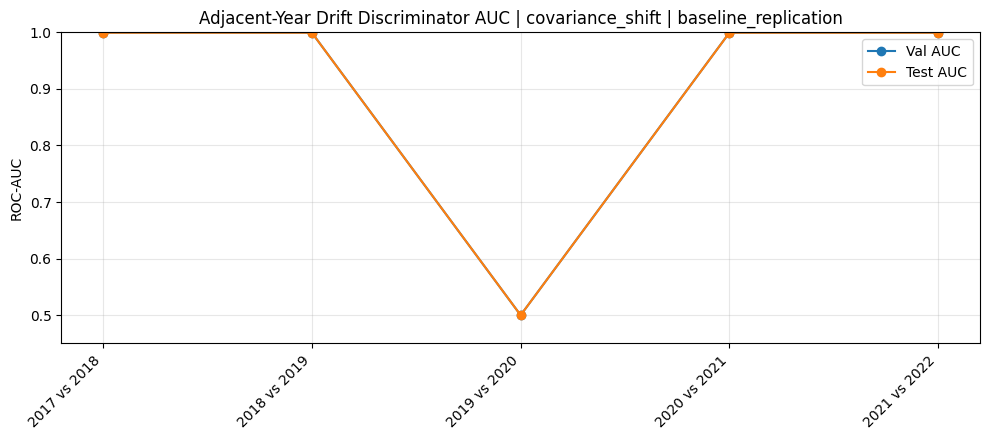


### Running mode: per_year_original
Artifact: covariance_shift | per_year_original
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9990 | Test AUC = 0.9988 | Val F1 = 0.9963 | Test F1 = 0.9962

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9993 | Test AUC = 0.9991 | Val F1 = 0.9974 | Test F1 = 0.9963

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5621 | Test AUC = 0.5404 | Val F1 = 0.5596 | Test F1 = 0.5371

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9987 | Test AUC = 0.9987 | Val F1 = 0.9944 | Test F1 = 0.9945

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9986 | Test AUC = 0.9988 | Val F1 = 0.9947 | Test F1 = 0.9947

COMPLETE: covariance_shift | per_year_original
Elapsed: 1320.7s (22.0m)
Pairs trained: 5
Average time per pair: 264.1s
Min/Max AUC (test): 0.540 / 0.999



,method,mode,artifact_label,zarr_path,metadata_path,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec,changed_years,perturb_year_values
0,covariance_shift,per_year_original,covariance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2017 vs 2018,2017,2018,11192640,2546360,2566882,0.999032,0.998849,0.996270,0.996175,1145.840949,None,"[2018, 2021]"
1,covariance_shift,per_year_original,covariance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2018 vs 2019,2018,2019,11192640,2546360,2566882,0.999252,0.999073,0.997418,0.996300,46.037630,None,"[2018, 2021]"
2,covariance_shift,per_year_original,covariance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2019 vs 2020,2019,2020,11192640,2546360,2566882,0.562070,0.540384,0.559630,0.537114,45.069945,None,"[2018, 2021]"
3,covariance_shift,per_year_original,covariance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2020 vs 2021,2020,2021,11192640,2546360,2566882,0.998670,0.998712,0.994366,0.994458,42.342780,None,"[2018, 2021]"
4,covariance_shift,per_year_original,covariance_shift | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2021 vs 2022,2021,2022,11192640,2546360,2566882,0.998626,0.998789,0.994716,0.994657,41.400070,None,"[2018, 2021]"


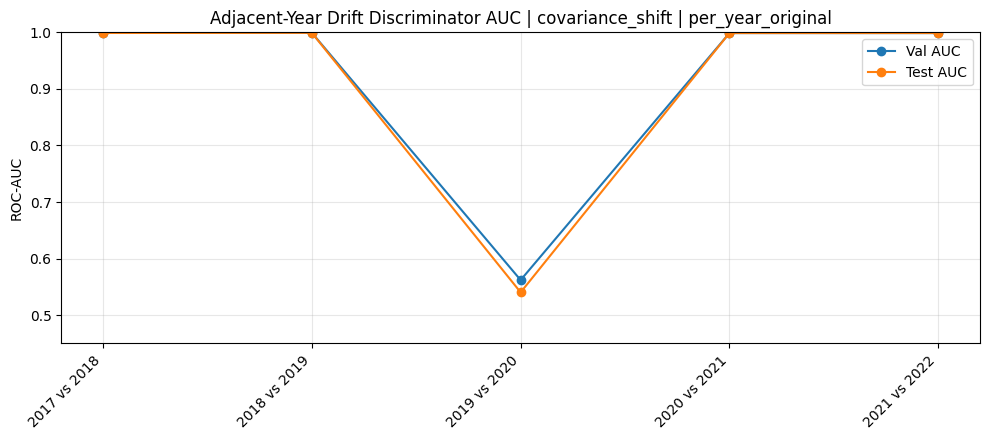

Covariance shift combined view:


,mode,mean_val_auc,mean_test_auc,mean_test_f1,n_pairs
0,baseline_replication,0.899568,0.899491,0.920642,5
1,per_year_original,0.911530,0.907161,0.903741,5


In [8]:
section_results["covariance_shift"] = run_method_section(
    method_name="covariance_shift",
    sample_fraction=SAMPLE_FRACTION,
 )

cov_combined = section_results["covariance_shift"]["combined"]
if not cov_combined.empty:
    print("Covariance shift combined view:")
    display(
        cov_combined.groupby(["mode"], as_index=False)
        .agg(
            mean_val_auc=("val_auc", "mean"),
            mean_test_auc=("test_auc", "mean"),
            mean_test_f1=("test_f1", "mean"),
            n_pairs=("pair", "count"),
        )
    )

## Noise Injection

Run discriminator on synthetic artifacts generated with `noise_injection` for both modes.


### Running mode: baseline_replication
Artifact: noise_injection | baseline_replication
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6238 | Test F1 = 0.6203

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.4999 | Test AUC = 0.5000 | Val F1 = 0.6210 | Test F1 = 0.6170

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.4999 | Test AUC = 0.5000 | Val F1 = 0.6093 | Test F1 = 0.6058

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6286 | Test F1 = 0.6252

COMPLETE: noise_injection | baseline_replication
Elapsed: 218.1s (3.6m)
Pairs trained: 5
Average time per pair: 43.6s
Min/Max AUC (test): 0.500 / 0.500



,method,mode,artifact_label,zarr_path,metadata_path,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec,changed_years,perturb_year_values
0,noise_injection,baseline_replication,noise_injection | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2017 vs 2018,2017,2018,11181600,2544088,2564324,0.500016,0.500006,0.623832,0.620331,42.397244,None,"[2018, 2021]"
1,noise_injection,baseline_replication,noise_injection | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2018 vs 2019,2018,2019,11181600,2544088,2564324,0.499934,0.500006,0.620998,0.617022,46.187451,None,"[2018, 2021]"
2,noise_injection,baseline_replication,noise_injection | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2019 vs 2020,2019,2020,11181600,2544088,2564324,0.500000,0.500000,0.622278,0.618576,43.940463,None,"[2018, 2021]"
3,noise_injection,baseline_replication,noise_injection | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2020 vs 2021,2020,2021,11181600,2544088,2564324,0.499875,0.499962,0.609308,0.605790,41.650022,None,"[2018, 2021]"
4,noise_injection,baseline_replication,noise_injection | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2021 vs 2022,2021,2022,11181600,2544088,2564324,0.499974,0.500048,0.628606,0.625229,43.952724,None,"[2018, 2021]"


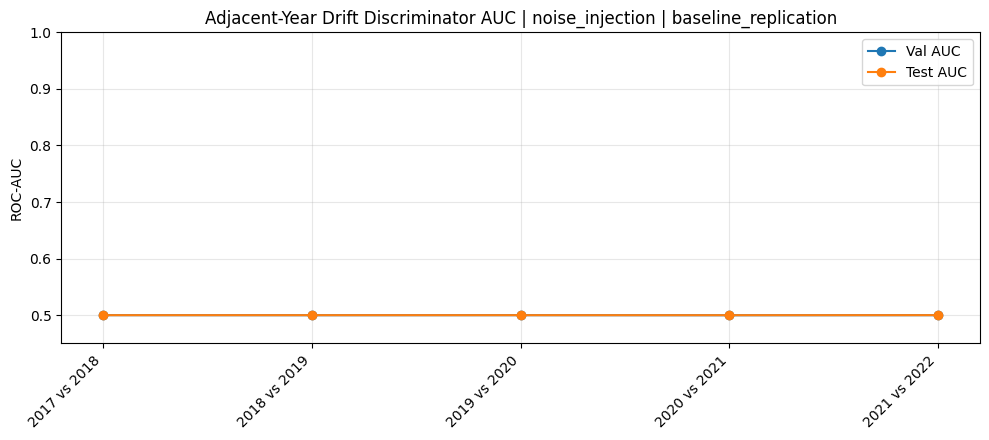


### Running mode: per_year_original
Artifact: noise_injection | per_year_original
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-noise_injection_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.6522 | Test AUC = 0.6475 | Val F1 = 0.6120 | Test F1 = 0.6131

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.7216 | Test AUC = 0.7093 | Val F1 = 0.6554 | Test F1 = 0.6483

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5621 | Test AUC = 0.5404 | Val F1 = 0.5597 | Test F1 = 0.5372

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.5807 | Test AUC = 0.5711 | Val F1 = 0.5474 | Test F1 = 0.5465

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.6647 | Test AUC = 0.6714 | Val F1 = 0.6353 | Test F1 = 0.6411

COMPLETE: noise_injection | per_year_original
Elapsed: 220.4s (3.7m)
Pairs trained: 5
Average time per pair: 44.1s
Min/Max AUC (test): 0.540 / 0.709



,method,mode,artifact_label,zarr_path,metadata_path,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec,changed_years,perturb_year_values
0,noise_injection,per_year_original,noise_injection | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2017 vs 2018,2017,2018,11192640,2546360,2566882,0.652228,0.647489,0.612017,0.613110,44.072745,None,"[2018, 2021]"
1,noise_injection,per_year_original,noise_injection | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2018 vs 2019,2018,2019,11192640,2546360,2566882,0.721610,0.709282,0.655377,0.648255,44.937201,None,"[2018, 2021]"
2,noise_injection,per_year_original,noise_injection | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2019 vs 2020,2019,2020,11192640,2546360,2566882,0.562066,0.540401,0.559655,0.537192,44.217654,None,"[2018, 2021]"
3,noise_injection,per_year_original,noise_injection | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2020 vs 2021,2020,2021,11192640,2546360,2566882,0.580687,0.571098,0.547408,0.546456,43.529242,None,"[2018, 2021]"
4,noise_injection,per_year_original,noise_injection | per_year_original,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...,2021 vs 2022,2021,2022,11192640,2546360,2566882,0.664696,0.671380,0.635327,0.641076,43.682050,None,"[2018, 2021]"


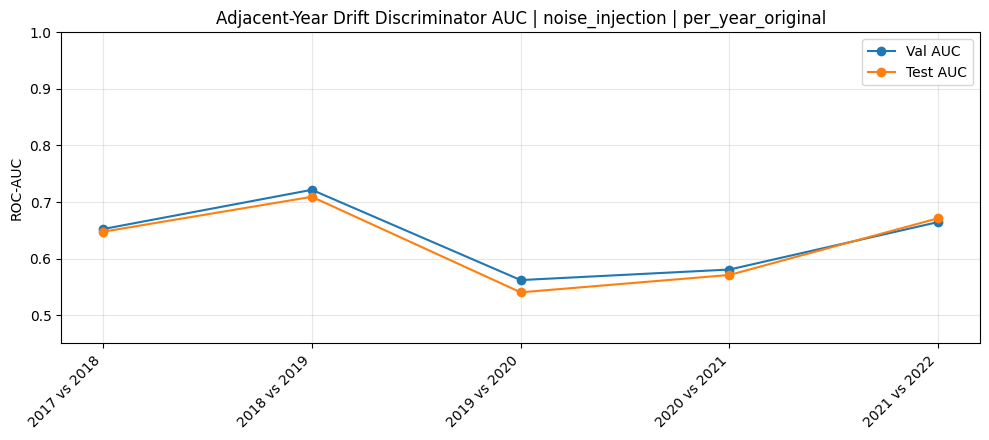

Noise injection combined view:


,mode,mean_val_auc,mean_test_auc,mean_test_f1,n_pairs
0,baseline_replication,0.499960,0.500004,0.617389,5
1,per_year_original,0.636257,0.627930,0.597218,5


In [9]:
section_results["noise_injection"] = run_method_section(
    method_name="noise_injection",
    sample_fraction=SAMPLE_FRACTION,
 )

noise_combined = section_results["noise_injection"]["combined"]
if not noise_combined.empty:
    print("Noise injection combined view:")
    display(
        noise_combined.groupby(["mode"], as_index=False)
        .agg(
            mean_val_auc=("val_auc", "mean"),
            mean_test_auc=("test_auc", "mean"),
            mean_test_f1=("test_f1", "mean"),
            n_pairs=("pair", "count"),
        )
    )

## Cross-Method Summary

Consolidate all method runs into one comparison table and aggregate chart.

Collected rows: 30


,method,mode,artifact_label,zarr_path,metadata_path,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec,changed_years,perturb_year_values
0,mean_variance_shift,baseline_replication,mean_variance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2017 vs 2018,2017,2018,11181600,2544088,2564324,0.946350,0.949031,0.884259,0.885971,96.992970,None,"[2018, 2021]"
1,mean_variance_shift,baseline_replication,mean_variance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2018 vs 2019,2018,2019,11181600,2544088,2564324,0.946251,0.949004,0.886585,0.887149,74.754489,None,"[2018, 2021]"
2,mean_variance_shift,baseline_replication,mean_variance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2019 vs 2020,2019,2020,11181600,2544088,2564324,0.500000,0.500000,0.622278,0.618576,74.810088,None,"[2018, 2021]"
3,mean_variance_shift,baseline_replication,mean_variance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2020 vs 2021,2020,2021,11181600,2544088,2564324,0.946350,0.949031,0.884259,0.885971,75.079813,None,"[2018, 2021]"
4,mean_variance_shift,baseline_replication,mean_variance_shift | baseline_replication,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...,2021 vs 2022,2021,2022,11181600,2544088,2564324,0.946251,0.949004,0.886585,0.887149,68.430418,None,"[2018, 2021]"


Method/mode summary:


,method,mode,mean_test_auc,mean_val_auc,mean_test_f1,n_pairs
0,covariance_shift,baseline_replication,0.899491,0.899568,0.920642,5
1,covariance_shift,per_year_original,0.907161,0.911530,0.903741,5
2,mean_variance_shift,baseline_replication,0.859214,0.857040,0.832963,5
3,mean_variance_shift,per_year_original,0.853711,0.853487,0.799617,5
4,noise_injection,baseline_replication,0.500004,0.499960,0.617389,5
5,noise_injection,per_year_original,0.627930,0.636257,0.597218,5


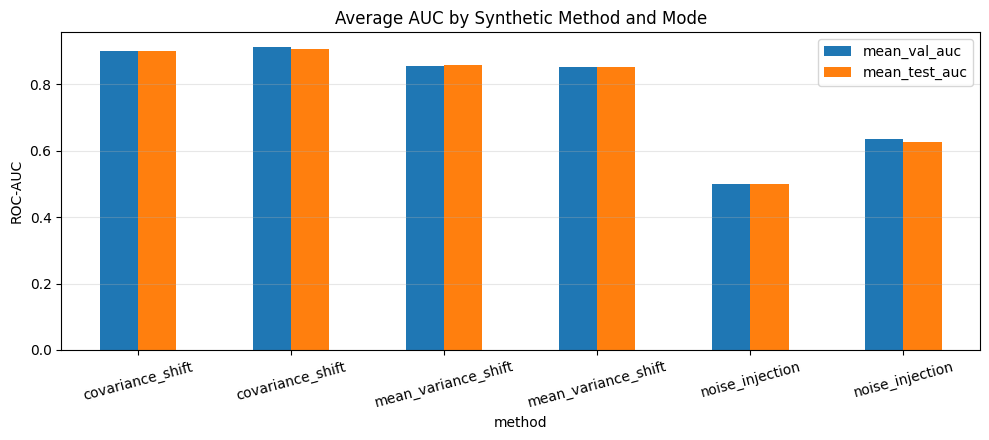

In [10]:
available = {
    k: v for k, v in section_results.items()
    if isinstance(v, dict) and not v.get("combined", pd.DataFrame()).empty
}

if not available:
    print("No method results available yet. Run the method section cells first.")
else:
    all_results = pd.concat([v["combined"] for v in available.values()], ignore_index=True)
    print(f"Collected rows: {len(all_results)}")
    display(all_results.head())

    summary = (
        all_results.groupby(["method", "mode"], as_index=False)
        .agg(
            mean_test_auc=("test_auc", "mean"),
            mean_val_auc=("val_auc", "mean"),
            mean_test_f1=("test_f1", "mean"),
            n_pairs=("pair", "count"),
        )
        .sort_values(["method", "mode"])
        .reset_index(drop=True)
    )

    print("Method/mode summary:")
    display(summary)

    ax = summary.plot(
        x="method",
        y=["mean_val_auc", "mean_test_auc"],
        kind="bar",
        figsize=(10, 4.5),
        rot=15,
        title="Average AUC by Synthetic Method and Mode",
    )
    ax.set_ylabel("ROC-AUC")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()